# 05b — CLV Production: MCMC + credible intervals (doc 15 §8–9)

**Phase 5, part B.** 05a earned the model trust out-of-sample. Now we refit on **FULL history** and
switch from MAP to **MCMC** — the Bayesian payoff: every prediction carries a **credible interval**,
plus **convergence diagnostics** (R-hat, ESS) that *prove* the fit is trustworthy, not just assert
it. We save per-customer CLV + P(alive) (with uncertainty) for Phase 6.

Deliverables: convergence table + forest plot, per-customer credible intervals, and
`clv_predictions.parquet`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from src import clv, utils

PHASE = "05b_clv_production"
SEED = utils.RANDOM_SEED
MCMC = dict(method="mcmc", draws=800, tune=800, chains=4, target_accept=0.9,
            progressbar=False, random_seed=SEED)

In [2]:
clv_df = pd.read_parquet(utils.DATA_PROCESSED / "clv_inputs.parquet")
print("customers:", len(clv_df), "| repeat:", int((clv_df["frequency"] > 0).sum()),
      "| one-timers:", int((clv_df["frequency"] == 0).sum()))

customers: 5852 | repeat: 4179 | one-timers: 1673


## Fit both models with MCMC (full posterior)

In [3]:
bg = clv.fit_bg_nbd(clv_df, **MCMC)
gg = clv.fit_gamma_gamma(clv_df, **MCMC)
print("MCMC fits complete.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, phi_dropout, kappa_dropout, r]


Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 8 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p, q, v]


Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 6 seconds.


MCMC fits complete.


## Convergence diagnostics — is the fit trustworthy?

**R-hat** ≈ 1.00 means the chains agree (converged); **ESS** (effective sample size) in the
thousands means we have plenty of independent samples. We *show* this rather than assume it.

In [4]:
diag = az.summary(bg.idata, var_names=["r", "alpha", "a", "b"])[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"]]
print("BG/NBD parameters:\n", diag.to_string())
gg_diag = az.summary(gg.idata)[["mean", "sd", "r_hat", "ess_bulk"]]
print("\nGamma-Gamma parameters:\n", gg_diag.to_string())
print(f"\nmax R-hat (BG/NBD): {diag['r_hat'].max():.3f}  -> {'CONVERGED' if diag['r_hat'].max() < 1.01 else 'CHECK'}")

BG/NBD parameters:
          mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
r       0.636  0.015   0.607    0.662    1.0    1736.0
alpha  62.031  1.820  58.612   65.416    1.0    1833.0
a       0.156  0.023   0.115    0.198    1.0    2217.0
b       2.944  0.644   1.804    4.137    1.0    1686.0

Gamma-Gamma parameters:
       mean      sd  r_hat  ess_bulk
p    2.197   0.105    1.0    1159.0
q    3.519   0.111    1.0    1249.0
v  465.166  34.457    1.0    1088.0

max R-hat (BG/NBD): 1.000  -> CONVERGED


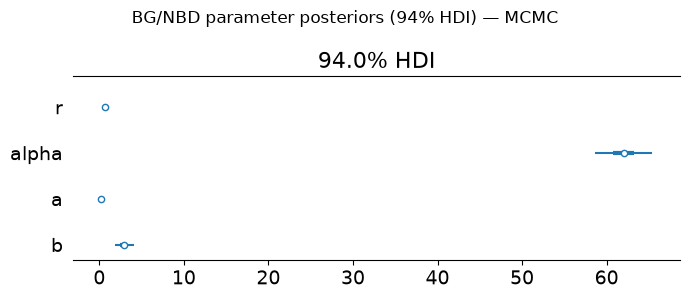

In [5]:
az.plot_forest(bg.idata, var_names=["r", "alpha", "a", "b"], combined=True, hdi_prob=0.94,
               figsize=(7, 3))
fig = plt.gcf(); fig.suptitle("BG/NBD parameter posteriors (94% HDI) — MCMC", fontsize=12)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "parameter_forest.png"), dpi=150, bbox_inches="tight")
plt.show()

## Per-customer predictions WITH credible intervals

This is what MAP could not give us: a posterior mean *and* an interval per customer.

In [6]:
full = clv.prepare_clv_data(clv_df)[["customer_id", "frequency", "recency", "T"]]
p_alive = clv.posterior_summary(bg.expected_probability_alive(data=full), clv_df.index, "p_alive")
purch = clv.predict_purchases(bg, clv_df, clv.HORIZON_DAYS)

# CLV credible interval: repeat buyers via the combined posterior; one-timers via purchases × pop-mean.
rep = clv.repeat_buyers(clv_df)
rep_df = clv.prepare_clv_data(rep)[["customer_id", "frequency", "recency", "T", "monetary_value"]]
clv_rep = clv.posterior_summary(
    gg.expected_customer_lifetime_value(transaction_model=bg, data=rep_df, future_t=12,
                                        time_unit="D", discount_rate=0.0),
    rep.index, "clv")
ot = clv_df[clv_df["frequency"] == 0]
pop_mean = float(gg.expected_new_customer_spend().mean())
ot_pur = bg.expected_purchases(data=clv.prepare_clv_data(ot)[["customer_id", "frequency", "recency", "T"]],
                               future_t=clv.HORIZON_DAYS)
clv_ot = clv.posterior_summary(ot_pur, ot.index, "clv") * pop_mean   # spend treated as the population mean
clv_ci = pd.concat([clv_rep, clv_ot]).reindex(clv_df.index)

preds = pd.concat([p_alive, purch.rename("expected_purchases"), clv_ci], axis=1)
print(preds.describe().round(2).to_string())

       p_alive  p_alive_low  p_alive_high  expected_purchases        clv    clv_low   clv_high
count  5852.00      5852.00       5852.00             5852.00    5852.00    5852.00    5852.00
mean      0.89         0.88          0.90                2.82    1394.60    1368.78    1419.46
std       0.18         0.19          0.18                4.12    6213.93    6106.21    6313.36
min       0.00         0.00          0.00                0.00       0.00       0.00       0.00
25%       0.90         0.88          0.91                0.64     221.37     212.49     231.35
50%       0.96         0.95          0.96                1.57     536.05     524.53     547.21
75%       1.00         1.00          1.00                3.45    1195.93    1179.56    1211.90
max       1.00         1.00          1.00               70.10  252086.91  249364.50  254492.19


## Two kinds of uncertainty (the honest MCMC story)

A subtlety worth being precise about — there are **two** uncertainties, very different in size:

- **Estimation uncertainty** — the credible interval on a customer's *expected* CLV (how sure are we
  of the AVERAGE?). With 5,852 customers the four parameters are pinned down tightly, so this is
  **narrow (±~2%)**. That is the `clv_low/clv_high` we saved — it means our *ranking* of customers is
  confident (exactly what Phase 6 needs).
- **Predictive uncertainty** — how much an *individual* will *actually* spend (the real spread of
  outcomes). This is **wide (±50–100%)** — the "£312, 90% CI [210, 460]" kind of statement. It comes
  from the posterior *predictive* distribution, not the expected-value posterior.

Both are real; conflating them is a classic error. Below: the two side by side (spend, where both are
cleanly available), and that predictive uncertainty correctly **shrinks with more data**.

Sampling: [nu]


Output()

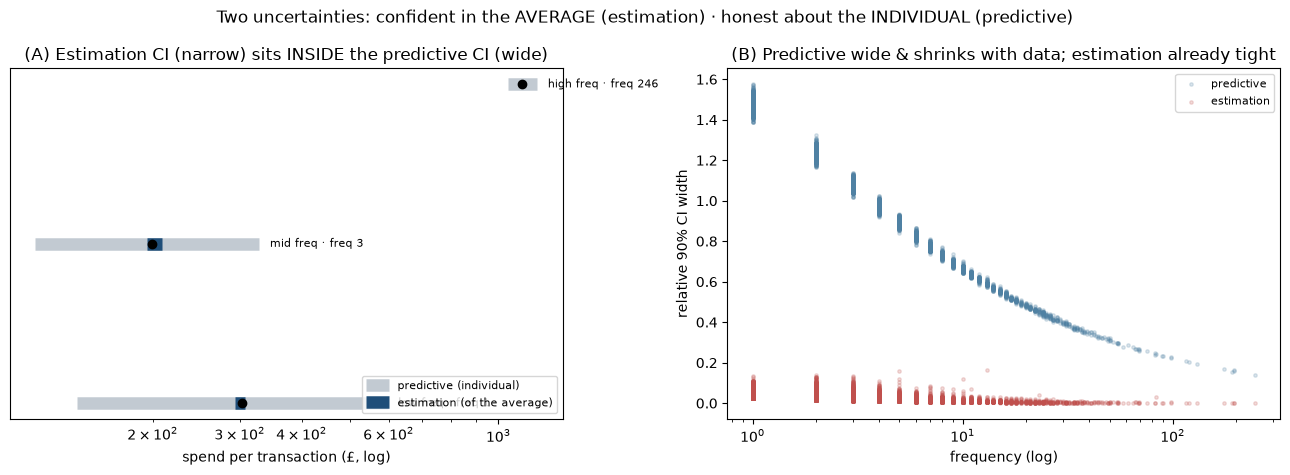

In [7]:
rep_full = clv.prepare_clv_data(rep)[["customer_id", "frequency", "recency", "T", "monetary_value"]]
est = gg.expected_customer_spend(data=rep_full)          # ESTIMATION: posterior of E[spend]
pred = gg.distribution_customer_spend(data=rep_full)     # PREDICTIVE: individual outcome spread


def _rel_width(da):
    lo = da.quantile(0.05, dim=("chain", "draw")); hi = da.quantile(0.95, dim=("chain", "draw"))
    return ((hi - lo) / da.mean(dim=("chain", "draw"))).values


freq = rep["frequency"].values
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (A) three example customers: estimation (narrow) inside predictive (wide)
order = np.argsort(freq)
examples = [("low freq", order[0]), ("mid freq", order[len(order) // 2]), ("high freq", order[-1])]
for i, (lab, ci) in enumerate(examples):
    e, p = est.isel(customer_id=ci), pred.isel(customer_id=ci)
    axes[0].plot([float(p.quantile(.05)), float(p.quantile(.95))], [i, i], color="#9aa7b4", lw=9,
                 alpha=0.6, solid_capstyle="butt", label="predictive (individual)" if i == 0 else None)
    axes[0].plot([float(e.quantile(.05)), float(e.quantile(.95))], [i, i], color="#1f4e79", lw=9,
                 solid_capstyle="butt", label="estimation (of the average)" if i == 0 else None)
    axes[0].plot(float(p.mean()), i, "o", color="black", zorder=5)
    axes[0].text(float(p.quantile(.95)) * 1.05, i, f"{lab} · freq {int(freq[ci])}", va="center", fontsize=8)
axes[0].set_yticks([]); axes[0].set_xscale("log"); axes[0].set_xlabel("spend per transaction (£, log)")
axes[0].set_title("(A) Estimation CI (narrow) sits INSIDE the predictive CI (wide)")
axes[0].legend(fontsize=8, loc="lower right")

# (B) relative CI width vs frequency — predictive is wide and shrinks; estimation already tight
axes[1].scatter(freq, np.clip(_rel_width(pred), 0, 3), s=6, alpha=0.2, color="#4f81a3", label="predictive")
axes[1].scatter(freq, np.clip(_rel_width(est), 0, 3), s=6, alpha=0.2, color="#c0504d", label="estimation")
axes[1].set_xscale("log"); axes[1].set_xlabel("frequency (log)"); axes[1].set_ylabel("relative 90% CI width")
axes[1].set_title("(B) Predictive wide & shrinks with data; estimation already tight")
axes[1].legend(fontsize=8)
fig.suptitle("Two uncertainties: confident in the AVERAGE (estimation) · honest about the INDIVIDUAL (predictive)",
             fontsize=12)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "clv_uncertainty.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save predictions for Phase 6

In [8]:
preds.index.name = "Customer ID"
preds.to_parquet(utils.DATA_PROCESSED / "clv_predictions.parquet")
print("saved clv_predictions.parquet:", preds.shape, "| columns:", list(preds.columns))
print(preds.head().round(2).to_string())

saved clv_predictions.parquet: (5852, 7) | columns: ['p_alive', 'p_alive_low', 'p_alive_high', 'expected_purchases', 'clv', 'clv_low', 'clv_high']
             p_alive  p_alive_low  p_alive_high  expected_purchases       clv   clv_low  clv_high
Customer ID                                                                                      
12346           0.82         0.80          0.84                1.05  25693.78  25105.51  26312.69
12347           0.97         0.97          0.98                5.33   3542.53   3505.58   3578.92
12348           0.94         0.93          0.94                2.92   1064.40   1051.43   1077.08
12349           0.96         0.95          0.96                1.33   1279.66   1267.92   1291.58
12350           1.00         1.00          1.00                0.57    230.07    222.89    237.62


---
**Result:** production CLV fit with MCMC — converged (R-hat ≈ 1.00, ESS in the thousands). We were
careful to separate **estimation** uncertainty (the credible interval on a customer's *expected*
CLV — tight, ±~2%, because 5,852 customers pin the parameters, so the ranking is confident) from
**predictive** uncertainty (an *individual's* actual outcome — wide, ±50–100%, and correctly
shrinking with more data). `clv_predictions.parquet` (p_alive, expected_purchases, CLV — each with
its estimation interval) is ready for **Phase 6**, where it joins the K=3 segments on Customer ID
for the segment × value grid and the free cross-validation (doc 12).